In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
block_size = 3
X, Y = [], []

for w in words:
        # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [21]:
X.shape

torch.Size([228146, 3])

In [17]:
C = torch.randn((27, 2))

In [28]:
emb = C[X]
emb

tensor([[[ 2.1647,  0.9446],
         [ 2.1647,  0.9446],
         [ 2.1647,  0.9446]],

        [[ 2.1647,  0.9446],
         [ 2.1647,  0.9446],
         [ 1.0090,  0.2435]],

        [[ 2.1647,  0.9446],
         [ 1.0090,  0.2435],
         [ 1.3826,  0.2142]],

        ...,

        [[-0.9165, -0.6392],
         [-0.9165, -0.6392],
         [ 0.0582,  1.4105]],

        [[-0.9165, -0.6392],
         [ 0.0582,  1.4105],
         [-0.9165, -0.6392]],

        [[ 0.0582,  1.4105],
         [-0.9165, -0.6392],
         [ 1.1721,  0.9130]]])

In [29]:
W1 = torch.randn((6, 100))
b1  = torch.randn((100))

In [30]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[ 0.7721, -0.9998,  0.9997,  ...,  1.0000, -0.9877,  0.9994],
        [-0.1586, -1.0000,  0.9980,  ...,  1.0000, -0.9974,  0.9998],
        [-0.6088, -0.9996,  0.9850,  ...,  0.9993, -0.9465,  0.9983],
        ...,
        [ 0.9020,  0.9846,  0.8886,  ..., -0.9252,  0.7239, -0.9988],
        [ 0.3147, -0.8499, -0.0080,  ...,  0.1609, -0.9894,  0.9864],
        [-0.9159,  0.6263, -0.2388,  ...,  0.7585,  0.4631,  0.6455]])

In [31]:
h.shape

torch.Size([228146, 100])

In [35]:
W2 = torch.randn((100, 27))
b2 = torch.randn((27))

In [36]:
logits = h @ W2 + b2
counts = logits.exp()
counts

tensor([[3.7879e+04, 9.2243e-08, 9.0684e+05,  ..., 3.2019e+04, 2.6437e-01,
         1.1562e-02],
        [8.5674e+04, 4.2002e-03, 1.0579e+05,  ..., 2.5858e+05, 1.8751e+00,
         8.4260e-02],
        [1.6626e+03, 4.1859e-06, 2.0092e+02,  ..., 3.9516e+04, 1.2543e-04,
         1.6088e+00],
        ...,
        [4.9512e-02, 1.2802e+02, 2.4308e-01,  ..., 2.7785e-02, 3.2032e+00,
         2.5041e-01],
        [1.6574e-01, 8.2806e+01, 2.1048e+05,  ..., 4.7738e-01, 2.2430e-03,
         4.1563e+03],
        [2.4407e-05, 6.9384e-04, 1.1738e-02,  ..., 2.0877e-01, 7.8998e-02,
         5.9180e-04]])

In [37]:
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(17.7082)

In [44]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn((100), generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

3481


In [40]:
# ix = torch.randint(0, X.shape[0], (32,))
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
print(loss)
loss = F.cross_entropy(logits, Y)
print(loss)

tensor(19.5052)
tensor(19.5052)


In [46]:
for p in parameters:
    p.requires_grad = True

In [45]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre
print(lrs)

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [47]:
lri = []
lossi = []
epoch = 1000
for i in range(epoch):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    for p in parameters:
        p.grad = None
    loss.backward()
    # print(f'{loss=}')

    lr = 10 ** lre[i]
    for p in parameters:
        p.data += -lr * p.grad
    lri.append(lre[i].item())
    lossi.append(loss.item())
    if i == 0 or i == epoch-1:
        print(f'{loss=}')

loss=tensor(21.5926, grad_fn=<NllLossBackward0>)
loss=tensor(9.6064, grad_fn=<NllLossBackward0>)


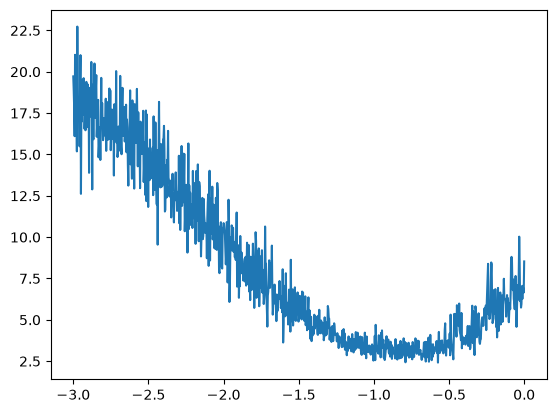

In [24]:
plt.plot(lri, lossi)

In [49]:
def build_data(words):
    X, Y = [], []
    block_size = 3
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return (X, Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_data(words[:n1]) # %80
Xdev, Ydev = build_data(words[n1:n2]) #10
Xte, Yte = build_data(words[n2:]) #10

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [65]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn((200), generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

11897


In [66]:
lossi = []
epoch = 40000
for i in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    lossi.append(loss.item())
    if i % 10000 == 0 or i == epoch-1:
        print(f'{loss=}')

loss=tensor(20.4060, grad_fn=<NllLossBackward0>)
loss=tensor(2.9385, grad_fn=<NllLossBackward0>)
loss=tensor(2.3540, grad_fn=<NllLossBackward0>)
loss=tensor(2.2216, grad_fn=<NllLossBackward0>)
loss=tensor(2.2802, grad_fn=<NllLossBackward0>)


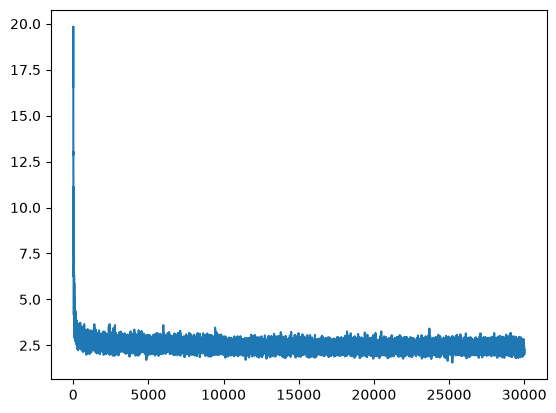

In [54]:
plt.plot(lossi)

In [58]:
minibatch train loss: 2.2913
train loss: 2.3902
dev loss: 2.3890

train loss: 2.2905
dev loss: 2.3004

SyntaxError: invalid syntax (2015570724.py, line 1)

In [68]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(f'{loss=}')

loss=tensor(2.2905, grad_fn=<NllLossBackward0>)


In [69]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(f'{loss=}')

loss=tensor(2.3004, grad_fn=<NllLossBackward0>)


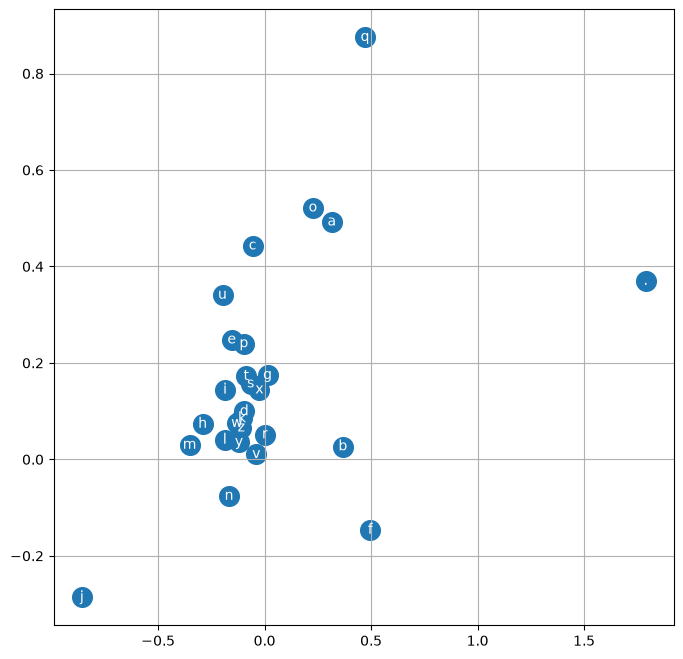

In [70]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [71]:
g = torch.Generator().manual_seed(2147483647)

block_size = 3

for i in range(30):
    out = []
    context = block_size * [0]
    while True:
        emb = C[torch.tensor(context)]
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

cenbe.
lomonuraice.
kayha.
malich.
tainella.
kamania.
samiyah.
javhrigotis.
moriel.
kau.
keptedorea.
emia.
sadly.
tiaverry.
fobt.
mhiniden.
tahlasu.
juf.
del.
wil.
pyaw.
ivan.
juridin.
kamer.
der.
jairet.
kai.
ajahzabellah.
kiys.
qey.
